<a href="https://colab.research.google.com/github/soumyanildey/Machine-Learning-Projects/blob/main/Flickr8kProject_Personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import os
from transformers import VisionEncoderDecoderModel, AutoProcessor, AutoTokenizer, TrainingArguments, Trainer, AutoModel, AutoModelForCausalLM, AutoModelForSeq2SeqLM, GPT2Config
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import random
from transformers.modeling_outputs import BaseModelOutput
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import (
    AutoFeatureExtractor,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    default_data_collator,
)
from transformers import ViTModel, GPT2LMHeadModel, VisionEncoderDecoderModel
from torch import nn
from transformers import PreTrainedModel, ViTConfig

from transformers import BioGptTokenizer, BioGptForCausalLM, set_seed, T5ForConditionalGeneration, AutoImageProcessor
import wandb
wandb.init(mode="disabled")
!pip install datasets
from google.colab import drive
drive.mount('/content/drive')
!pip install nltk rouge-score evaluate
import nltk
nltk.download('punkt')
nltk.download('wordnet')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
import torch
import torch.nn as nn
from transformers import (
    ViTModel, ViTConfig,
    GPT2Config, AutoModelForCausalLM,
    VisionEncoderDecoderModel,
    AutoImageProcessor, AutoTokenizer
)

# === VisionEncoderDecoder with ViT256 + GPT-2 === #
vit_model_name = "google/vit-base-patch16-224"  # ViT with 256x256 support
decoder_model_name = "gpt2"

# Combine into VisionEncoderDecoderModel
model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained('google/vit-base-patch16-224', 'gpt2')

# Image processor and tokenizer
processor = AutoImageProcessor.from_pretrained(vit_model_name,use_fast=True)
tokenizer = AutoTokenizer.from_pretrained(decoder_model_name)

# Add special tokens if needed
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
if tokenizer.bos_token is None or tokenizer.eos_token is None:
    tokenizer.add_special_tokens({
        'bos_token': '[CLS]',
        'eos_token': '[SEP]'
    })

# Resize decoder embeddings only
model.decoder.resize_token_embeddings(len(tokenizer))

# Set generation config
model.config.decoder_start_token_id = tokenizer.bos_token_id or tokenizer.cls_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id or tokenizer.sep_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Beam search config
model.config.max_length = 128
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_a

In [3]:
# Iterate over named parameters
for name, param in model.named_parameters():
    print(f"Parameter name: {name}")
    print(f"Parameter shape: {param.shape}")
    print(f"Requires gradient: {param.requires_grad}")
    print("-" * 20)

Parameter name: encoder.embeddings.cls_token
Parameter shape: torch.Size([1, 1, 768])
Requires gradient: True
--------------------
Parameter name: encoder.embeddings.position_embeddings
Parameter shape: torch.Size([1, 197, 768])
Requires gradient: True
--------------------
Parameter name: encoder.embeddings.patch_embeddings.projection.weight
Parameter shape: torch.Size([768, 3, 16, 16])
Requires gradient: True
--------------------
Parameter name: encoder.embeddings.patch_embeddings.projection.bias
Parameter shape: torch.Size([768])
Requires gradient: True
--------------------
Parameter name: encoder.encoder.layer.0.attention.attention.query.weight
Parameter shape: torch.Size([768, 768])
Requires gradient: True
--------------------
Parameter name: encoder.encoder.layer.0.attention.attention.query.bias
Parameter shape: torch.Size([768])
Requires gradient: True
--------------------
Parameter name: encoder.encoder.layer.0.attention.attention.key.weight
Parameter shape: torch.Size([768, 768

In [4]:
print(model)

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [5]:
from datasets import load_dataset

ds = load_dataset("jxie/flickr8k")

In [6]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

In [7]:
total_caption_lengths = []

# Helper to collect lengths from a split
def collect_caption_lengths(split):
    for caption_column in ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']:
        total_caption_lengths.extend(
            [len(tokenizer.encode(caption, truncation=False)) for caption in split[caption_column]]
        )

# Process each split
collect_caption_lengths(ds['train'])
collect_caption_lengths(ds['validation'])
collect_caption_lengths(ds['test'])

# Get max length
max_length = max(total_caption_lengths)
print("Maximum caption length:", max_length)


Maximum caption length: 41


In [8]:
print(tokenizer.model_max_length)  # Returns model's max token limit


1024


In [9]:
from torch.utils.data import Dataset
import torch

class MultiCaptionImageDataset(Dataset):
    def __init__(self, hf_dataset, processor, tokenizer, max_length):
        self.dataset = hf_dataset
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Each image will generate 5 rows (one for each caption)
        return len(self.dataset) * 5

    def __getitem__(self, idx):
        # For each row, determine which image-caption pair we are fetching
        image_idx = idx // 5  # Integer division to get the image index
        caption_idx = idx % 5  # Modulo to get which caption (0 to 4) for this row

        item = self.dataset[image_idx]

        image = item["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Process image
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        # Access the selected caption
        caption_column = f"caption_{caption_idx}"  # Dynamically select caption_0 to caption_4
        caption = item[caption_column]

        # Tokenize caption
        tokenized = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].squeeze(0)
        attention_mask = tokenized["attention_mask"].squeeze(0)

        # Mask loss on padding
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "attention_mask": attention_mask
        }


In [10]:
from torch.utils.data import DataLoader


train_dataset = MultiCaptionImageDataset(ds['train'], processor, tokenizer, max_length)
val_dataset = MultiCaptionImageDataset(ds['validation'], processor, tokenizer, max_length)
test_dataset = MultiCaptionImageDataset(ds['test'], processor, tokenizer, max_length)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers = 2)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers = 2, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers = 2, shuffle = False)


In [11]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

30000 5000 5000


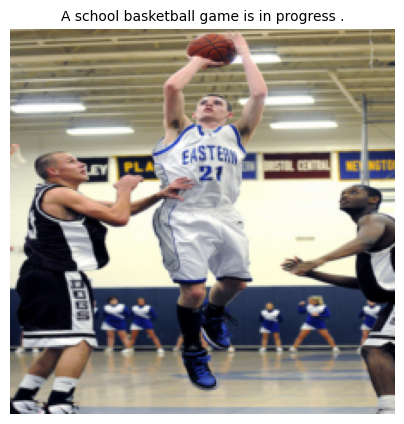

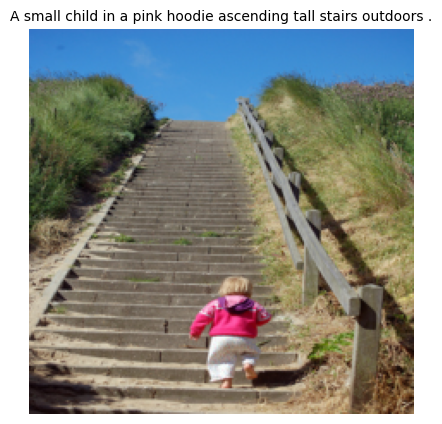

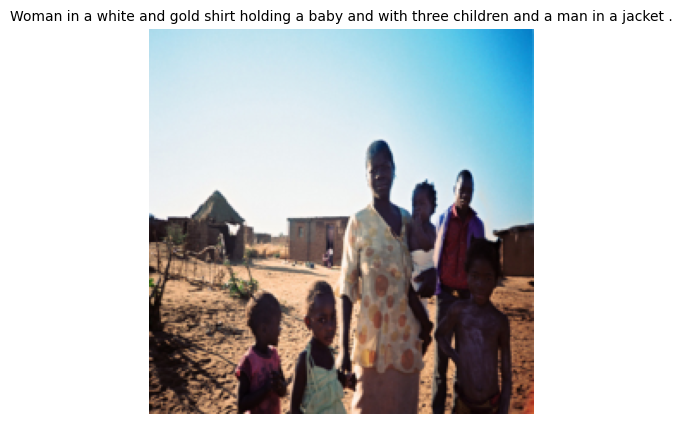

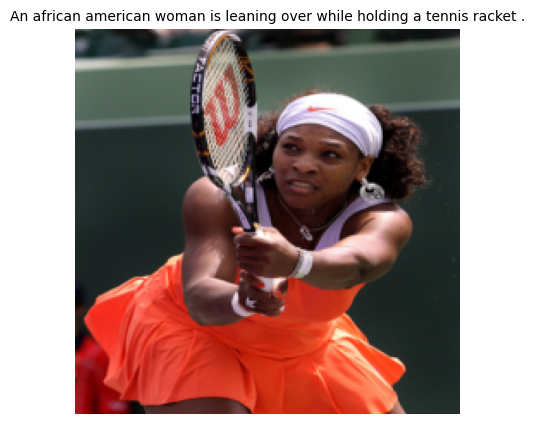

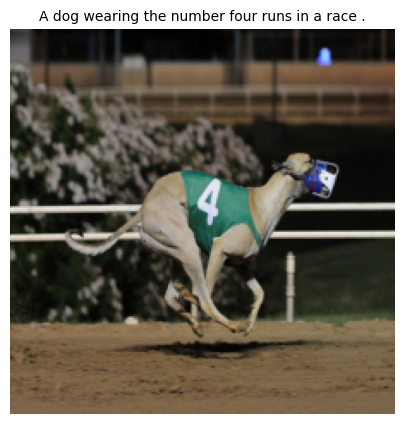

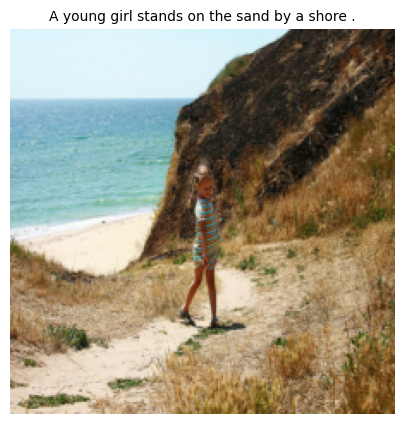

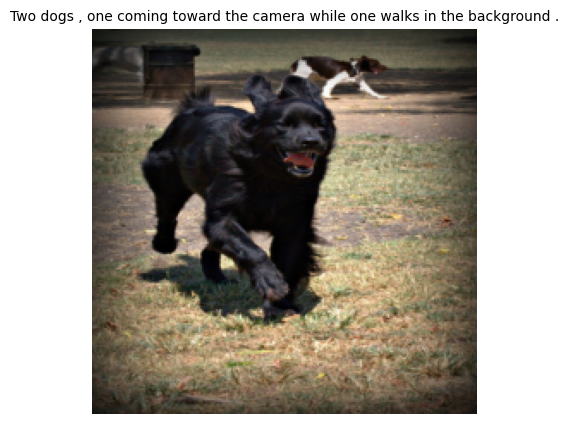

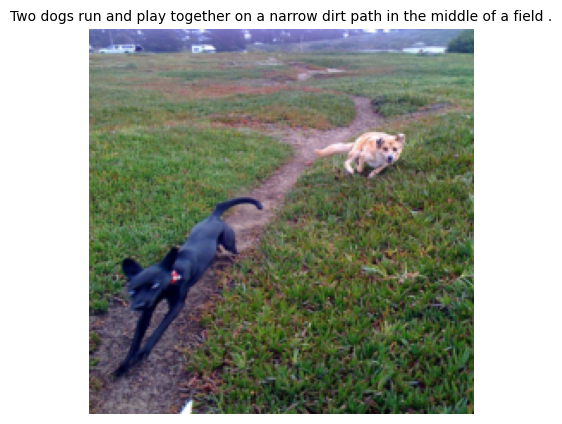

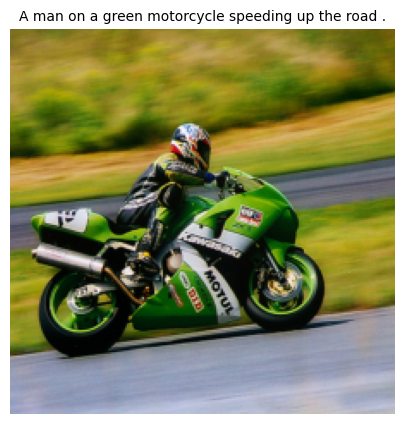

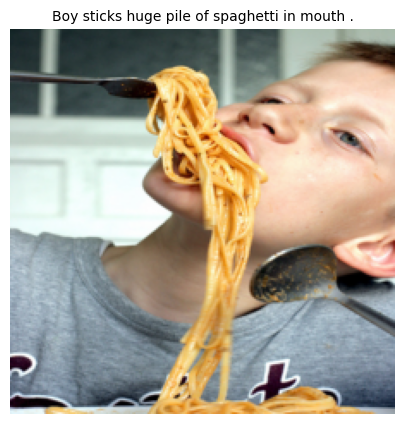

In [12]:
import matplotlib.pyplot as plt

def show_images_and_captions(data_loader, tokenizer, max_samples=10):
    shown = 0  # Counter for shown samples

    for batch in data_loader:
        pixel_values = batch['pixel_values']
        labels = batch['labels']

        for i in range(len(pixel_values)):
            if shown >= max_samples:
                return  # Stop after showing max_samples

            # Convert image to HxWxC format and normalize
            image = pixel_values[i].permute(1, 2, 0).numpy()
            image = (image - image.min()) / (image.max() - image.min())

            # Filter out -100 from labels before decoding
            caption_ids = [id for id in labels[i].tolist() if id != -100]

            # Decode caption safely
            try:
                caption = tokenizer.decode(caption_ids, skip_special_tokens=True) if caption_ids else "Empty caption"
            except Exception as e:
                caption = f"Decoding error: {e}"

            # Show image with caption
            plt.figure(figsize=(5, 5))
            plt.imshow(image)
            plt.axis('off')
            plt.title(caption, fontsize=10)
            plt.show()

            shown += 1
show_images_and_captions(train_loader, tokenizer, max_samples=10)


In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import time
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
nltk.download("punkt")

# Metric setup
smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rouge3', 'rouge4', 'rougeL'], use_stemmer=True)

def compute_metrics(reference, hypothesis):
    ref = [reference.split()]
    hyp = hypothesis.split()
    scores = {}

    for i in range(1, 5):
        weights = tuple([1 / i] * i + [0] * (4 - i))
        scores[f"BLEU-{i}"] = sentence_bleu(ref, hyp, weights=weights, smoothing_function=smoothie)

    rouge_scores = rouge.score(reference, hypothesis)
    for key in rouge_scores:
        scores[f"{key.upper()}"] = rouge_scores[key].fmeasure

    return scores

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}, GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
model.to(device)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1, threshold=0.03,
    threshold_mode='rel', min_lr=1e-6, verbose=True,
)

# Mixed precision
scaler = GradScaler()
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    epoch_start_time = time.time()
    print(f"\n🧪 Epoch {epoch + 1}/{num_epochs}")
    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for step, batch in enumerate(progress_bar):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)


        optimizer.zero_grad()
        with autocast():
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)
        progress_bar.set_postfix(loss=f"{avg_loss:.4f}")

    train_loss = running_loss / len(train_loader)
    print(f"✅ Train Loss: {train_loss:.4f} | Time: {(time.time() - epoch_start_time) / 60:.2f} min")

    # Validation
    model.eval()
    val_loss = 0.0
    all_metrics = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)


            with autocast():
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss += outputs.loss.item()

                # Generate captions
                gen_ids = model.generate(pixel_values=pixel_values, max_new_tokens=50)
                preds = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

                # Clean label sequences by removing -100s
                cleaned_labels = []
                for label_seq in labels:
                    cleaned_seq = [token_id.item() for token_id in label_seq if token_id.item() != -100]
                    cleaned_labels.append(cleaned_seq)

                refs = tokenizer.batch_decode(cleaned_labels, skip_special_tokens=True)

                # Compute metrics
                for ref, pred in zip(refs, preds):
                    metrics = compute_metrics(ref.strip(), pred.strip())
                    all_metrics.append(metrics)

    avg_val_loss = val_loss / len(val_loader)
    print(f"🔍 Validation Loss: {avg_val_loss:.4f}")

    # Aggregate metrics
    avg_metrics = {k: sum(m[k] for m in all_metrics) / len(all_metrics) for k in all_metrics[0]}
    for name, value in avg_metrics.items():
        print(f"{name}: {value:.4f}")

    # LR Scheduler
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr < prev_lr:
        print(f"📉 LR reduced from {prev_lr:.6f} to {new_lr:.6f}")
    else:
        print(f"⚠️ LR not reduced. Still at {new_lr:.6f}")
        print(f"🧠 Best val loss so far (tracked by scheduler): {scheduler.best:.6f}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using device: cuda, GPU: Tesla T4


<ipython-input-13-00924218e810>:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🧪 Epoch 1/5


Training:   0%|          | 0/938 [00:00<?, ?it/s]<ipython-input-13-00924218e810>:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


✅ Train Loss: 4.5051 | Time: 8.69 min


Validation:   0%|          | 0/157 [00:00<?, ?it/s]<ipython-input-13-00924218e810>:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.11/dist-packages/transformers/generation/utils.py:1667: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


🔍 Validation Loss: 4.0445
BLEU-1: 0.0979
BLEU-2: 0.0317
BLEU-3: 0.0170
BLEU-4: 0.0106
ROUGE1: 0.2686
ROUGE2: 0.0121
ROUGE3: 0.0002
ROUGE4: 0.0000
ROUGEL: 0.2074
⚠️ LR not reduced. Still at 0.000050
🧠 Best val loss so far (tracked by scheduler): 4.044548

🧪 Epoch 2/5


✅ Train Loss: 3.8481 | Time: 8.63 min


Validation:  74%|███████▍  | 116/157 [08:22<02:57,  4.34s/it]

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import evaluate

nltk.download('punkt')
nltk.download('wordnet')

meteor = evaluate.load("meteor")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def collate_fn(batch):
    images = [item["image"].convert("RGB") for item in batch]
    captions = [item[f"caption_{i}"] for item in batch for i in range(5)]
    return {"image": images, "caption": captions}

# Sample subset
sample_test_ds = Subset(ds['test'], indices=range(8))
test_loader = DataLoader(sample_test_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)

gen_kwargs = {
    "max_new_tokens": 30,              # Limit the caption length (excluding input tokens)
    "num_beams": 5,                    # Use beam search for better captions
    "early_stopping": True,           # Stop when all beams reach EOS
    "length_penalty": 0.8,            # Shorter captions are preferred
    "no_repeat_ngram_size": 3,        # Avoid repeating trigrams
    "pad_token_id": tokenizer.pad_token_id
}


# Visualization
def show_image_with_caption(image, reference, generated, idx):
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"\n🟢 Reference: {reference.strip()}\n🔵 Generated: {generated.strip()}",
        fontsize=10,
        wrap=True
    )
    plt.tight_layout()
    plt.show()

# Metrics
smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_metrics(reference, hypothesis):
    ref = [reference.split()]
    hyp = hypothesis.split()
    scores = {}

    for i in range(1, 5):
        scores[f"BLEU-{i}"] = sentence_bleu(ref, hyp, weights=tuple([1/i]*i), smoothing_function=smoothie)

    rouge_scores = rouge.score(reference, hypothesis)
    scores["ROUGE-1"] = rouge_scores["rouge1"].fmeasure
    scores["ROUGE-2"] = rouge_scores["rouge2"].fmeasure
    scores["ROUGE-L"] = rouge_scores["rougeL"].fmeasure

    meteor_result = meteor.compute(predictions=[hypothesis], references=[[reference]])
    scores["METEOR"] = meteor_result["meteor"]

    return scores

# Inference loop
print("📷 Generating captions...\n")
with torch.no_grad():
    for batch in tqdm(test_loader):
        raw_images = batch["image"]
        references = batch["caption"]

        # Single image processor
        pixel_values = processor(images=raw_images, return_tensors="pt").pixel_values.to(device)

        # Generate captions
        outputs = model.generate(pixel_values=pixel_values, **gen_kwargs)
        generated_captions = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        for i in range(len(raw_images)):
            img_np = np.array(raw_images[i])
            reference = references[i]
            hypothesis = generated_captions[i]

            show_image_with_caption(img_np, reference, hypothesis, i + 1)
            metrics = compute_metrics(reference, hypothesis)
            for name, value in metrics.items():
                print(f"{name}: {value:.4f}")
            print()
